In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/rubyestrickland/Desktop/EnvDataSci/HW05/LA_AQS_2023 (2).csv')
print(df.head())

   State Code  County Code  Site Number  Parameter Code  POC  Latitude  \
0           6           37         1103           68103    1  34.06659   
1           6           37         1103           42602    3  34.06659   
2           6           37         1103           62201    1  34.06659   
3           6           37         1103           62101    1  34.06659   
4           6           37         1103           42603    1  34.06659   

   Longitude  Datum            Parameter Name Duration Description  ... AQI  \
0 -118.22688  WGS84   Ambient Min Temperature              24 HOUR  ...   .   
1 -118.22688  WGS84    Nitrogen dioxide (NO2)               1 HOUR  ...  16   
2 -118.22688  WGS84         Relative Humidity               1 HOUR  ...   .   
3 -118.22688  WGS84       Outdoor Temperature               1 HOUR  ...   .   
4 -118.22688  WGS84  Oxides of nitrogen (NOx)               1 HOUR  ...   .   

  Daily Criteria Indicator  Tribe Name  State Name  County Name    City Name  \


In [3]:
df_ml = pd.read_csv('/Users/rubyestrickland/Desktop/EnvDataSci/HW05/ManuaLoa_CO2.csv')
print(df_ml.head())

   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99
3  1958      6     1958.4548   317.24          315.14     -1 -9.99 -0.99
4  1958      7     1958.5370   315.86          315.18     -1 -9.99 -0.99


In [4]:
df_O3 = df[(df['Parameter Name']=='Ozone') & (df['Duration Description']=='1 HOUR')]
df_NO2 = df[(df['Parameter Name'] == 'Nitrogen dioxide (NO2)') & (df['Duration Description'] == '1 HOUR')]

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

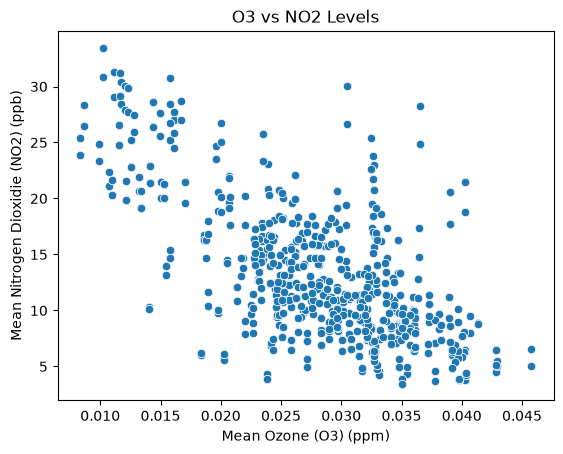

In [9]:
df_combined = pd.merge(
    df_O3, 
    df_NO2, 
    on="Day In Year (Local)",         
    suffixes=("_O3", "_NO2"))
sns.scatterplot(
    data=df_combined, 
    x="Arithmetic Mean_O3", 
    y="Arithmetic Mean_NO2")
plt.xlabel("Mean Ozone (O3) (ppm)")
plt.ylabel("Mean Nitrogen Dioxidie (NO2) (ppb)")
plt.title("O3 vs NO2 Levels")
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Get sklearn! https://scikit-learn.org/stable/
from sklearn import linear_model

In [12]:
O3Val = np.array(df_combined['Arithmetic Mean_O3']).reshape((-1, 1))
NO2Val = np.array(df_combined['Arithmetic Mean_NO2'])

reg = linear_model.LinearRegression()
reg.fit(O3Val,NO2Val)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-544.53]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.54
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[0.25]


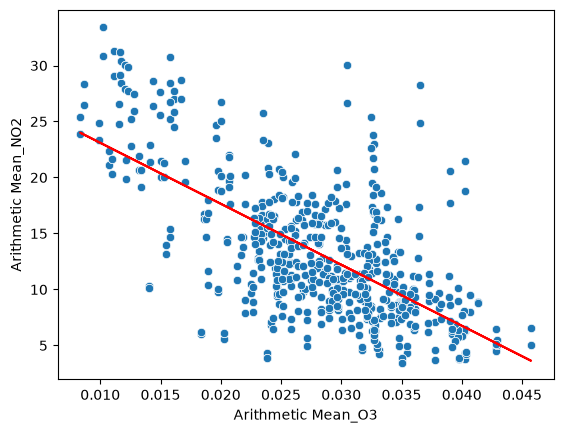

In [14]:
yPred = reg.predict(O3Val)

df_combined['yPred'] = yPred
sns.scatterplot(data=df_combined, x="Arithmetic Mean_O3", y="Arithmetic Mean_NO2")
plt.plot(df_combined['Arithmetic Mean_O3'], df_combined['yPred'], color='r')

In [16]:
from sklearn.metrics import mean_squared_error
mean_squared_error(df_combined['Arithmetic Mean_NO2'],df_combined['yPred'])

21.630480529323975

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(O3Val, NO2Val, test_size=0.2)

In [18]:
reg2 = linear_model.LinearRegression()
reg2.fit(X_train,y_train)
print("Coefficients: \n", reg2.coef_)
print("Intercept: \n", reg2.intercept_)

Coefficients: 
 [-538.87234719]
Intercept: 
 28.392314899023965


In [19]:
X_test.ravel()

array([0.034583, 0.025625, 0.032583, 0.029333, 0.020667, 0.027125,
       0.02675 , 0.028958, 0.036375, 0.032125, 0.036375, 0.014375,
       0.021708, 0.0275  , 0.029217, 0.032708, 0.028167, 0.034792,
       0.018792, 0.025625, 0.018333, 0.03275 , 0.032708, 0.023833,
       0.038083, 0.030125, 0.022833, 0.024375, 0.022667, 0.029   ,
       0.01325 , 0.034667, 0.01975 , 0.039208, 0.024333, 0.033125,
       0.0295  , 0.025625, 0.030375, 0.033208, 0.029217, 0.034375,
       0.032792, 0.024167, 0.026167, 0.0365  , 0.039708, 0.02625 ,
       0.023542, 0.024875, 0.026625, 0.011667, 0.020292, 0.03775 ,
       0.023375, 0.01525 , 0.039208, 0.026792, 0.030167, 0.023208,
       0.027667, 0.025917, 0.032583, 0.035667, 0.026625, 0.027955,
       0.02075 , 0.025792, 0.033958, 0.023167, 0.036042, 0.029   ,
       0.028333, 0.03375 , 0.04025 , 0.0295  , 0.012292, 0.027125,
       0.026167, 0.0205  , 0.008333, 0.04025 , 0.016125, 0.012833,
       0.037792, 0.026625, 0.023833, 0.03525 , 0.023375, 0.011

In [20]:
#Plot Test Data
df_test = pd.DataFrame({'x' : X_test.ravel(), 'y' : y_test.ravel()})
df_test['yPred'] = reg2.predict(X_test)

Text(0, 0.5, 'Mean Nitrogen Dioxidie (NO2) (ppb)')

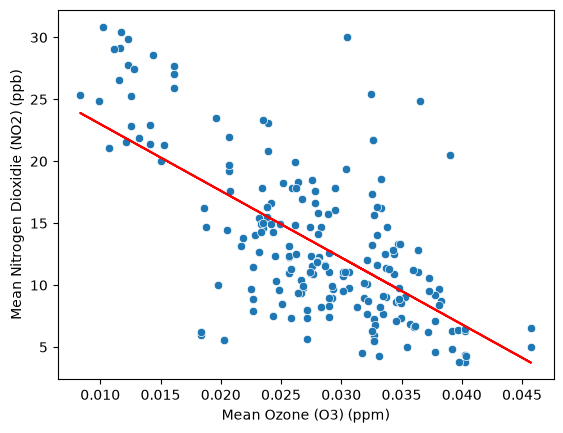

In [23]:
sns.scatterplot(data=df_test, x="x", y="y")
plt.plot(df_test['x'], df_test['yPred'], color='r')
plt.xlabel("Mean Ozone (O3) (ppm)")
plt.ylabel("Mean Nitrogen Dioxidie (NO2) (ppb)")

In [22]:
mean_squared_error(df_test['y'],df_test['yPred'])

22.54431255248558

In [24]:
print(df_ml.head())

   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99
3  1958      6     1958.4548   317.24          315.14     -1 -9.99 -0.99
4  1958      7     1958.5370   315.86          315.18     -1 -9.99 -0.99


In [26]:
filtered_mldf = df_ml[df_ml['year'] > 2000]

In [28]:
print(filtered_mldf.head())

     year  month  decimal date  average  deseasonalized  ndays  sdev   unc
514  2001      1     2001.0417   370.76          370.60     30  0.56  0.20
515  2001      2     2001.1250   371.69          370.95     26  0.61  0.23
516  2001      3     2001.2083   372.63          371.06     26  0.46  0.17
517  2001      4     2001.2917   373.55          370.99     29  0.56  0.20
518  2001      5     2001.3750   374.03          371.11     24  0.41  0.16


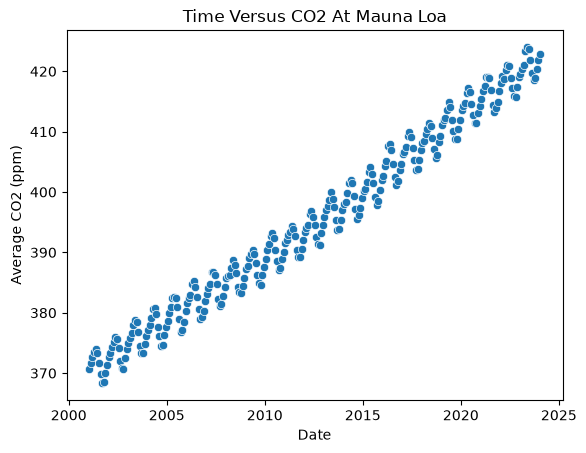

In [29]:
sns.scatterplot(x=filtered_mldf["decimal date"], y=filtered_mldf["average"])
plt.xlabel("Date")
plt.ylabel("Average CO2 (ppm)")
plt.title("Time Versus CO2 At Mauna Loa")
plt.show()

In [35]:
xVal = np.array(filtered_mldf['decimal date']).reshape((-1, 1))
yVal = np.array(filtered_mldf['average'])

reg = linear_model.LinearRegression()
reg.fit(xVal,yVal)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.25]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4134
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[110.9]


In [36]:
print("Coefficients: \n", reg.coef_)

Coefficients: 
 [2.25084015]


In [37]:
print("Intercept: \n", reg.intercept_)

Intercept: 
 -4134.490239508634


Text(0.5, 1.0, 'Linear Regression for Time Versus CO2 At Mauna Loa')

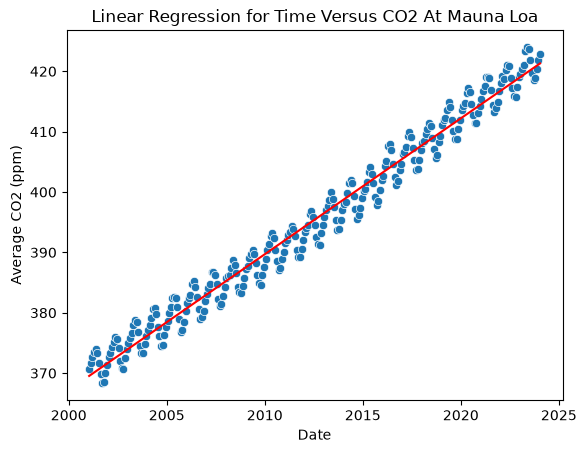

In [41]:
yPred = reg.predict(xVal)

filtered_mldf['yPred'] = yPred
sns.scatterplot(data=filtered_mldf, x="decimal date", y="average")
plt.plot(filtered_mldf['decimal date'], filtered_mldf['yPred'], color='r')
plt.xlabel("Date")
plt.ylabel("Average CO2 (ppm)")
plt.title("Linear Regression for Time Versus CO2 At Mauna Loa")

In [40]:
from sklearn.metrics import mean_squared_error
mean_squared_error(filtered_mldf['average'],filtered_mldf['yPred'])

5.410796527161714

In [42]:
df_ml = pd.read_csv('/Users/rubyestrickland/Desktop/EnvDataSci/HW05/ManuaLoa_CO2.csv')
print(df_ml.head())

   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99
3  1958      6     1958.4548   317.24          315.14     -1 -9.99 -0.99
4  1958      7     1958.5370   315.86          315.18     -1 -9.99 -0.99


In [43]:
filtered_dfml = df_ml[df_ml['year'] < 1999]

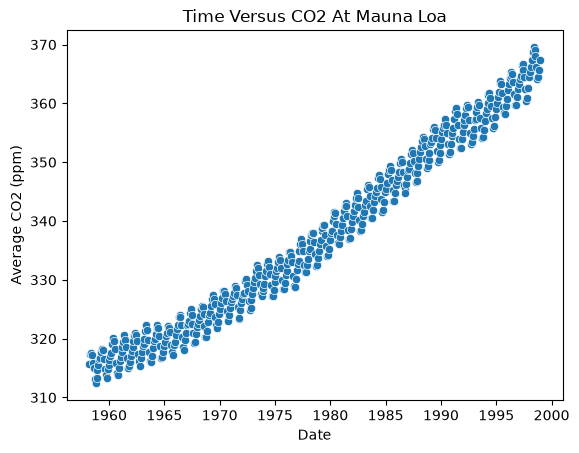

In [45]:
sns.scatterplot(x=filtered_dfml["decimal date"], y=filtered_dfml["average"])
plt.xlabel("Date")
plt.ylabel("Average CO2 (ppm)")
plt.title("Time Versus CO2 At Mauna Loa")
plt.show()

In [46]:
xVal = np.array(filtered_dfml['decimal date']).reshape((-1, 1))
yVal = np.array(filtered_dfml['average'])

reg = linear_model.LinearRegression()
reg.fit(xVal,yVal)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.31]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2257
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[260.95]


In [47]:
print("Coefficients: \n", reg.coef_)

Coefficients: 
 [1.31151953]


In [48]:
print("Intercept: \n", reg.intercept_)

Intercept: 
 -2257.3824779000865


Text(0.5, 1.0, 'Linear Regression for Time Versus CO2 At Mauna Loa')

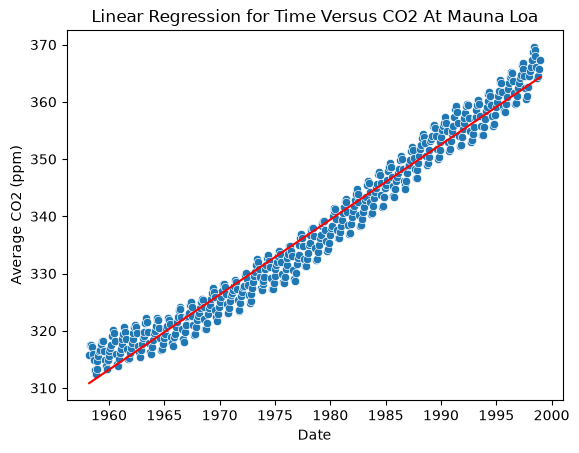

In [50]:
yPred = reg.predict(xVal)

filtered_dfml['yPred'] = yPred
sns.scatterplot(data=filtered_dfml, x="decimal date", y="average")
plt.plot(filtered_dfml['decimal date'], filtered_dfml['yPred'], color='r')
plt.xlabel("Date")
plt.ylabel("Average CO2 (ppm)")
plt.title("Linear Regression for Time Versus CO2 At Mauna Loa")

In [51]:
from sklearn.metrics import mean_squared_error
mean_squared_error(filtered_dfml['average'],filtered_dfml['yPred'])

7.209700550935123